In [1]:

using Markdown
using InteractiveUtils
using Graphs, Random, GraphPlot, Plots, Colors, GraphRecipes
using ITensors, ITensorMPS, LinearAlgebra
using Cairo, Fontconfig

In [2]:

function adj_mat_lin(N::Int)
    A = zeros(N, N)
    for i in 1:N-1
        A[i, i+1] = 1.0
        A[i+1, i] = 1.0
    end
    return A
end

function adj_mat_ent(N::Int)
    A = ones(N, N)
    A -= Matrix{Float64}(I, N, N) # Set diagonal to zero (no self-coupling)
    return A
end

function adj_mat_ent_weighted(N::Int, σ)
    A = zeros(Float64, N, N)
    for i in 1:N, j in (i+1):N
        weight = 1 + σ * randn()
        A[i, j] = A[j, i] = weight
    end
    return A
end

function adj_mat_rand(N, P)
    return Graphs.adjacency_matrix(Graphs.erdos_renyi(N, P))
end



adj_mat_rand (generic function with 1 method)

[0.0 1.0 0.0 0.0 0.0 0.0 0.0; 1.0 0.0 1.0 0.0 0.0 0.0 0.0; 0.0 1.0 0.0 1.0 0.0 0.0 0.0; 0.0 0.0 1.0 0.0 1.0 0.0 0.0; 0.0 0.0 0.0 1.0 0.0 1.0 0.0; 0.0 0.0 0.0 0.0 1.0 0.0 1.0; 0.0 0.0 0.0 0.0 0.0 1.0 0.0]


7×7 Matrix{Float64}:
 0.0  1.0  0.0  0.0  0.0  0.0  0.0
 1.0  0.0  1.0  0.0  0.0  0.0  0.0
 0.0  1.0  0.0  1.0  0.0  0.0  0.0
 0.0  0.0  1.0  0.0  1.0  0.0  0.0
 0.0  0.0  0.0  1.0  0.0  1.0  0.0
 0.0  0.0  0.0  0.0  1.0  0.0  1.0
 0.0  0.0  0.0  0.0  0.0  1.0  0.0

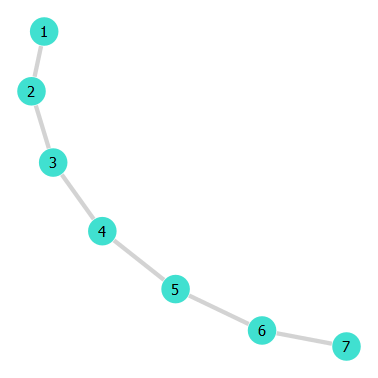

In [34]:
adjmat = adj_mat_lin(7)
println(adjmat)
display(adjmat)


G = Graphs.SimpleGraph(adjmat)
N = size(adjmat, 1)

node_labels = [string(i) for i in 1:N]

p = GraphPlot.gplot(
    G, 
    layout=spring_layout,
    nodelabel=node_labels,
    nodesize=0.3,
    nodelabelsize=3,
    edgelinewidth=2.0,
) 
display(p)


[0.0 1.0 1.0 1.0 1.0 1.0 1.0; 1.0 0.0 1.0 1.0 1.0 1.0 1.0; 1.0 1.0 0.0 1.0 1.0 1.0 1.0; 1.0 1.0 1.0 0.0 1.0 1.0 1.0; 1.0 1.0 1.0 1.0 0.0 1.0 1.0; 1.0 1.0 1.0 1.0 1.0 0.0 1.0; 1.0 1.0 1.0 1.0 1.0 1.0 0.0]


7×7 Matrix{Float64}:
 0.0  1.0  1.0  1.0  1.0  1.0  1.0
 1.0  0.0  1.0  1.0  1.0  1.0  1.0
 1.0  1.0  0.0  1.0  1.0  1.0  1.0
 1.0  1.0  1.0  0.0  1.0  1.0  1.0
 1.0  1.0  1.0  1.0  0.0  1.0  1.0
 1.0  1.0  1.0  1.0  1.0  0.0  1.0
 1.0  1.0  1.0  1.0  1.0  1.0  0.0

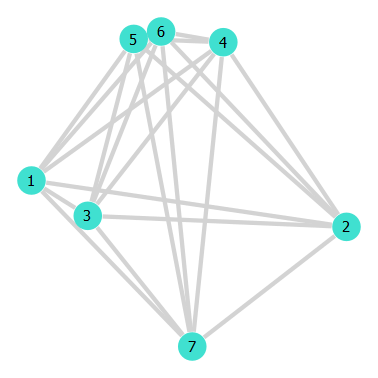

In [36]:
adjmat = adj_mat_ent(7)
println(adjmat)
display(adjmat)


G = Graphs.SimpleGraph(adjmat)
N = size(adjmat, 1)

node_labels = [string(i) for i in 1:N]

p = GraphPlot.gplot(
    G, 
    layout=random_layout,
    nodelabel=node_labels,
    nodesize=0.3,
    nodelabelsize=3,
    edgelinewidth=2.0,
) 
display(p)

[0.0 0.9178687736761488 1.0673361828410273 1.1240019004124362 0.9201421047513036 0.8212470422875287 0.6751005303188626; 0.9178687736761488 0.0 0.9930550679732328 1.414521180402821 1.0666881510347006 1.2079970853076047 0.9363177664429562; 1.0673361828410273 0.9930550679732328 0.0 0.8017473756757626 0.7429436687005857 1.6200422936790493 1.4270908386240695; 1.1240019004124362 1.414521180402821 0.8017473756757626 0.0 0.9722206680307403 0.8917816650338728 0.8589089708325695; 0.9201421047513036 1.0666881510347006 0.7429436687005857 0.9722206680307403 0.0 0.9632182254352566 1.2098420195575348; 0.8212470422875287 1.2079970853076047 1.6200422936790493 0.8917816650338728 0.9632182254352566 0.0 0.8703895150014225; 0.6751005303188626 0.9363177664429562 1.4270908386240695 0.8589089708325695 1.2098420195575348 0.8703895150014225 0.0]


7×7 Matrix{Float64}:
 0.0       0.917869  1.06734   1.124     0.920142  0.821247  0.675101
 0.917869  0.0       0.993055  1.41452   1.06669   1.208     0.936318
 1.06734   0.993055  0.0       0.801747  0.742944  1.62004   1.42709
 1.124     1.41452   0.801747  0.0       0.972221  0.891782  0.858909
 0.920142  1.06669   0.742944  0.972221  0.0       0.963218  1.20984
 0.821247  1.208     1.62004   0.891782  0.963218  0.0       0.87039
 0.675101  0.936318  1.42709   0.858909  1.20984   0.87039   0.0

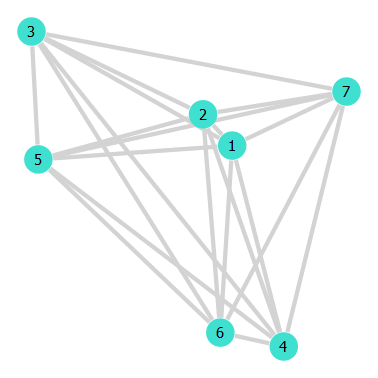

In [24]:
adjmat = adj_mat_ent_weighted(7, 0.2)
println(adjmat)
display(adjmat)


G = Graphs.SimpleGraph(adjmat)
N = size(adjmat, 1)

node_labels = [string(i) for i in 1:N]

p = GraphPlot.gplot(
    G, 
    layout=random_layout,
    nodelabel=node_labels,
    nodesize=0.3,
    nodelabelsize=3,
    edgelinewidth=2.0,
) 
display(p)

sparse([2, 3, 1, 4, 7, 1, 4, 6, 2, 3, 7, 3, 7, 2, 4, 6], [1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4, 6, 6, 7, 7, 7], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 7, 7)


7×7 SparseArrays.SparseMatrixCSC{Int64, Int64} with 16 stored entries:
 ⋅  1  1  ⋅  ⋅  ⋅  ⋅
 1  ⋅  ⋅  1  ⋅  ⋅  1
 1  ⋅  ⋅  1  ⋅  1  ⋅
 ⋅  1  1  ⋅  ⋅  ⋅  1
 ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅
 ⋅  ⋅  1  ⋅  ⋅  ⋅  1
 ⋅  1  ⋅  1  ⋅  1  ⋅

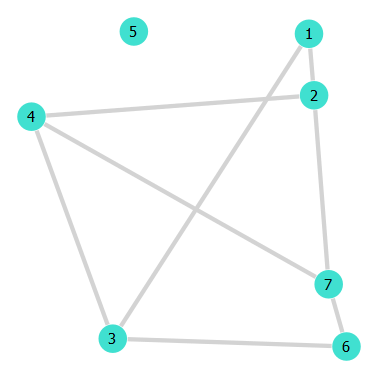

In [40]:
adjmat = adj_mat_rand(7, 0.4)
println(adjmat)
display(adjmat)


G = Graphs.SimpleGraph(adjmat)
N = size(adjmat, 1)

node_labels = [string(i) for i in 1:N]

p = GraphPlot.gplot(
    G, 
    layout=random_layout,
    nodelabel=node_labels,
    nodesize=0.3,
    nodelabelsize=3,
    edgelinewidth=2.0,
) 
display(p)